# Понижение размерности

In [ ]:
! pip install umap-learn

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn import datasets
from sklearn.datasets import load_iris
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as SKLDA
from sklearn.manifold import TSNE as SklearnTSNE
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier, NearestNeighbors
from sklearn.preprocessing import StandardScaler
import umap

np.random.seed(42)

In [ ]:
# загружаем iris и берём только первые 3 признака
iris = load_iris()
X = iris.data[:, :3]
y = iris.target

# стандартизируем
X_scaled = StandardScaler().fit_transform(X)

## **PCA**

In [ ]:
# Генерируем случайные данные
X = np.random.rand(10, 3)  # 10 наблюдений, 3 признака

In [ ]:
X

array([[0.37454012, 0.95071431, 0.73199394],
       [0.59865848, 0.15601864, 0.15599452],
       [0.05808361, 0.86617615, 0.60111501],
       [0.70807258, 0.02058449, 0.96990985],
       [0.83244264, 0.21233911, 0.18182497],
       [0.18340451, 0.30424224, 0.52475643],
       [0.43194502, 0.29122914, 0.61185289],
       [0.13949386, 0.29214465, 0.36636184],
       [0.45606998, 0.78517596, 0.19967378],
       [0.51423444, 0.59241457, 0.04645041]])

In [ ]:
# 1. Стандартизация данных
mean = np.mean(X, axis=0)
std = np.std(X, axis=0, ddof=1)  # ddof=1, чтобы совпадало со sklearn
X_std = (X - mean) / std

# 2. Вычисление матрицы Грама cразу на нормированных векторах
G = X_std.T @ X_std / (X_std.shape[0] - 1)

# 3. Нахождение собственных значений и векторов
eigenvalues, eigenvectors = np.linalg.eigh(G)

In [ ]:
eigenvalues

array([0.48260445, 1.02584333, 1.49155222])

In [ ]:
eigenvectors

array([[ 0.69686199, -0.05843807,  0.71482051],
       [ 0.656033  , -0.35083536, -0.66823293],
       [ 0.28983455,  0.93461197, -0.20614653]])

In [ ]:
# 4. Упорядочивание собственных значений и векторов по убыванию
idx = np.argsort(eigenvalues)[::-1]  # Индексы сортировки
eigenvalues = eigenvalues[idx]
eigenvectors = eigenvectors[:, idx]

In [ ]:
eigenvectors

array([[ 0.71482051, -0.05843807,  0.69686199],
       [-0.66823293, -0.35083536,  0.656033  ],
       [-0.20614653,  0.93461197,  0.28983455]])

In [ ]:
# 5. Проекция данных на главные компоненты
principal_components = X_std @ eigenvectors[:, :1]

principal_components

array([[-1.39412495],
       [ 1.27677047],
       [-2.03504024],
       [ 1.30267697],
       [ 1.81200474],
       [-0.47093337],
       [ 0.20620946],
       [-0.46178928],
       [-0.45193853],
       [ 0.21616472]])

In [ ]:
# PCA из sklearn
pca = PCA(n_components=1)
X_pca = pca.fit_transform(X_std)
X_pca

array([[-1.39412495],
       [ 1.27677047],
       [-2.03504024],
       [ 1.30267697],
       [ 1.81200474],
       [-0.47093337],
       [ 0.20620946],
       [-0.46178928],
       [-0.45193853],
       [ 0.21616472]])

In [ ]:
# Проверим точную разницу!
difference = np.abs(principal_components) - np.abs(X_pca)
print("Максимальная разница:\n", np.max(difference))

Максимальная разница:
 8.881784197001252e-16


## **t-SNE**

Для начала запишем функцию для расчёта евклидовых расстояний (формула разности квадратов)

In [ ]:
def pairwise_distances(X):
    """
    Функция для расчёта евклидовых расстояний
    ||x_i - x_j||^2 = x_i^2 + x_j^2 - 2*x_i*x_j
    """
    # n = X.shape[0]
    # D = np.zeros((n, n))
    # for i in range(n):
    #     for j in range(n):
    #         D[i, j] = np.sum((X[i] - X[j])**2)

    # а это оптимизированный вариант кода
    sq = np.sum(X * X, axis=1)
    D = -2 * X @ X.T + sq[:, None] + sq[None, :]
    D[D < 0] = 0

    return D

In [ ]:
pairwise_distances(X_scaled).shape, X_scaled.shape

((150, 150), (150, 3))

In [ ]:
D = pairwise_distances(X_scaled)

In [ ]:
D[10].argmin(), D[10].min()

(np.int64(10), np.float64(1.7763568394002505e-15))

Превращаем строку расстояний, получаемую в предыдущей функции, в вероятность:

$$
 dist\_row[i] = ||x_i - x_j||^2\;\;\; \rightarrow \;\;\; p_{j|i} = \frac{\exp(-|x_i - x_j|^2 / 2\sigma_i^2)}{\sum_{k\neq i} \exp(-|x_i - x_k|^2 / 2\sigma_i^2)},
$$

где $(2\sigma_i^2)^{-1} = \beta$

PS: $\sigma_i$ подбирается для каждой точки отдельно.

* $\beta$ больше $\Rightarrow \sigma$ меньше (распределение «уже», меньше соседей),
* $\beta$ меньше $\Rightarrow \sigma$ больше (распределение «шире», больше соседей).

In [ ]:
def compute_pi_row(
    dist_row,
    target_perp=30.0, # ~ у каждой точки примерно 30 соседей
    tol=1e-5,
    max_iter=50
):

    beta = 1.0  # = 1/(2σ^2)
    low, high = -np.inf, np.inf

    for _ in range(max_iter):
        P = np.exp(-dist_row * beta)
        P[dist_row < 1e-12] = 0
        P /= P.sum()

        # энтропия H(P)
        H = -np.sum(P * np.log(P + 1e-12))
        perp = np.exp(H)

        if abs(perp - target_perp) < tol:
            break

        if perp > target_perp: # perplexity слишком большая
            low = beta
            beta = beta * 2 if high == np.inf else (beta + high) / 2
        else: # perplexity слишком маленькая
            high = beta
            beta = beta / 2 if low == -np.inf else (beta + low) / 2

    return P

In [ ]:
P = compute_pi_row(D[10], target_perp=30)
P.shape

(150,)

In [ ]:
P.sum()

np.float64(1.0)

In [ ]:
P.argmin(), P.min()

(np.int64(10), np.float64(0.0))

In [ ]:
P.argmax(), P.max()

(np.int64(48), np.float64(0.06405859472932564))

In [ ]:
P[D[10] == 0]

array([], dtype=float64)

Формируем матрицу вероятностей. Важно выполнить симметризацию - перевести условные вероятности $p_{j|i}$ и $p_{i|j}$ в совместные $P_{ij}$, чтобы их можно было корректно сравнивать с $Q_{ij}$:

$$
P_{ij} = \frac{p_{j|i} + p_{i|j}}{2n}
$$

* До симметризации: «Как i видит j».

* После симметризации: «Как i и j обоюдно близки друг другу».

In [ ]:
def joint_probabilities(X, perplexity=30.0):
    """
    Расчёт матрицы вероятностей P
    """
    n = X.shape[0]
    D = pairwise_distances(X)
    P = np.zeros((n, n))

    for i in range(n):
        Pi = compute_pi_row(D[i], target_perp=perplexity)
        P[i, :] = Pi

    # симметризация по формуле Pij = (Pij + Pji) / (2n),
    P = (P + P.T) / (2 * n)
    return np.maximum(P, 1e-12)

In [ ]:
P_fin = joint_probabilities(X_scaled)
P_fin.shape

(150, 150)

In [ ]:
P_fin[:4, :4]

array([[1.00000000e-12, 3.75268607e-05, 7.94680409e-05, 4.37617878e-05],
       [3.75268607e-05, 1.00000000e-12, 2.59058325e-04, 3.10091331e-04],
       [7.94680409e-05, 2.59058325e-04, 1.00000000e-12, 3.47197135e-04],
       [4.37617878e-05, 3.10091331e-04, 3.47197135e-04, 1.00000000e-12]])

Расчёт q:
$$
q_{ij} = \frac{1}{1 + ||y_i - y_j||^2} \Big/ \sum_{k\neq l} ...
$$

In [ ]:
def compute_q(Y):
    n = Y.shape[0]
    Q_num = np.zeros((n, n))

    for i in range(n):
        for j in range(n):
            if i != j:
                Q_num[i, j] = 1 / (1 + np.sum((Y[i] - Y[j])**2))

    Q = Q_num / np.sum(Q_num)
    return Q, Q_num

Реализуем градиент для KL-дивергенции, вот сама формула:
$$
C = \mathrm{KL}(P|Q)
= \sum_{i}\sum_{j} p_{ij} \log \frac{p_{ij}}{q_{ij}}
$$

Вот её градиент:
$$
\frac{\partial C}{\partial y_i} =
4\sum_{j} \frac{(p_{ij} - q_{ij}) (y_i - y_j)}{(1 + ||y_i - y_j||^2)}
$$


In [ ]:
def compute_gradient(P, Q, Q_num, Y):
    n, dim = Y.shape
    grad = np.zeros_like(Y)

    for i in range(n):
        for j in range(n):
            if i != j:
                w = (P[i, j] - Q[i, j]) * Q_num[i, j]
                grad[i] += 4 * w * (Y[i] - Y[j])

    return grad

Финальная функция для реализации алгоритма!

PS: exaggeration искусственно увеличивает веса близких точек в начале обучения, чтобы кластеры сформировались чётче.

In [ ]:
def tsne_simple(
    X,
    n_components=2,
    perplexity=30,
    n_iter=500,
    lr=200
):
    n = X.shape[0]

    # инициализация Y
    Y = PCA(n_components=n_components).fit_transform(X)

    # считаем P
    P = joint_probabilities(X, perplexity)
    P *= 4  # early exaggeration

    Y_inc = np.zeros_like(Y)

    for it in range(n_iter):
        # считаем Q
        Q, Q_num = compute_q(Y)

        # градиент KL(P||Q)
        grad = compute_gradient(P, Q, Q_num, Y)

        # обновление
        Y_inc = 0.8 * Y_inc - lr * grad
        Y = Y + Y_inc

        if it == 100:
            P /= 4  # убираем exaggeration

    return Y

Протестируем:

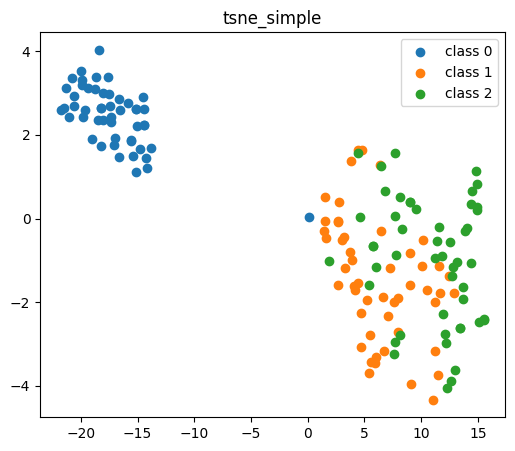

In [ ]:
Y_tsne = tsne_simple(X_scaled, n_components=2, perplexity=30, n_iter=500)

plt.figure(figsize=(6,5))
for label in np.unique(y):
    plt.scatter(Y_tsne[y==label, 0], Y_tsne[y==label, 1], label=f"class {label}")
plt.title("tsne_simple")
plt.legend()
plt.show()

/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


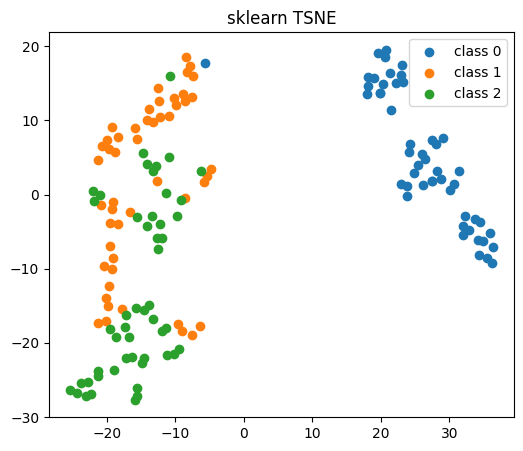

In [ ]:
tsne_skl = SklearnTSNE(
    n_components=2, perplexity=10, learning_rate=200,
    n_iter=500, init='pca', random_state=42
)
Y_skl = tsne_skl.fit_transform(X_scaled)

plt.figure(figsize=(6,5))
for label in np.unique(y):
    plt.scatter(Y_skl[y==label, 0], Y_skl[y==label, 1], label=f"class {label}")
plt.title("sklearn TSNE")
plt.legend()
plt.show()

## **UMAP**

Интерактивно поиграться с гиперпараметрами UMAP можно тут: https://pair-code.github.io/understanding-umap/

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


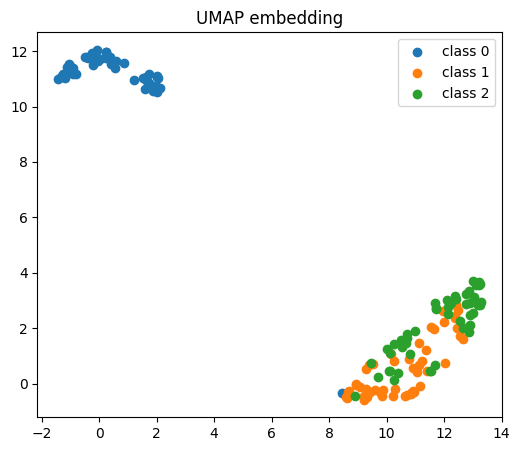

In [ ]:
# фитим umap
um = umap.UMAP(n_components=2, n_neighbors=30, min_dist=0.05, random_state=42)
X_umap = um.fit_transform(X_scaled)

# визуализация
plt.figure(figsize=(6,5))
for label in np.unique(y):
    plt.scatter(X_umap[y == label, 0], X_umap[y == label, 1], label=f"class {label}")
plt.title("UMAP embedding")
plt.legend()
plt.show()

## **LDA**

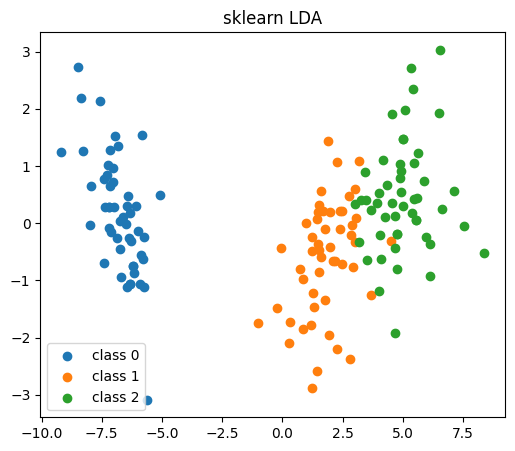

In [ ]:
lda = SKLDA(n_components=2)
X_lda_skl = lda.fit_transform(X_scaled, y) # придется передать метки

plt.figure(figsize=(6,5))
for label in np.unique(y):
    plt.scatter(X_lda_skl[y==label, 0], X_lda_skl[y==label, 1], label=f"class {label}")
plt.title("sklearn LDA")
plt.legend()
plt.show()